# Google Play review exploratory data analysis

This notebook analyzes the cleaned, aggregate-ready dataset produced by the Phase I pipeline. It covers review characteristics, metadata coverage, data quality, and meaningful differences across apps and categories.

> **Source limitation:** Google Play reviews are collected using the unofficial third-party `google-play-scraper` package, not a Google-supported API. Treat results as a dated prototype sample, not a comprehensive population estimate.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'analysis' else Path.cwd()
DATA = ROOT / 'data' / 'processed' / 'reviews_clean.csv'
QUALITY = ROOT / 'data' / 'quality' / 'quality_report.json'
ARTIFACTS = ROOT / 'artifacts'
ARTIFACTS.mkdir(exist_ok=True)

if not DATA.exists():
    raise FileNotFoundError(f'{DATA} does not exist. Run `python src/clean_reviews.py` first.')
df = pd.read_csv(DATA, parse_dates=['review_created_at', 'review_updated_at', 'collected_at'])
quality = json.loads(QUALITY.read_text()) if QUALITY.exists() else {}
df.shape

Matplotlib is building the font cache; this may take a moment.


(5500, 18)

## Dataset overview

In [2]:
overview = pd.Series({
    'clean_reviews': len(df),
    'apps': df['app_name'].nunique(),
    'categories': df['category'].nunique(),
    'collection_runs': df['run_id'].nunique(),
    'earliest_review': df['review_created_at'].min(),
    'latest_review': df['review_created_at'].max(),
})
overview

clean_reviews                           5500
apps                                      11
categories                                 7
collection_runs                            1
earliest_review    2025-03-08 21:08:11+00:00
latest_review      2026-09-29 20:21:25+00:00
dtype: object

## 1. Review characteristics

,rating_share,rating_count
rating,,
1,0.334000,1837
2,0.061818,340
3,0.058727,323
4,0.077273,425
5,0.468182,2575


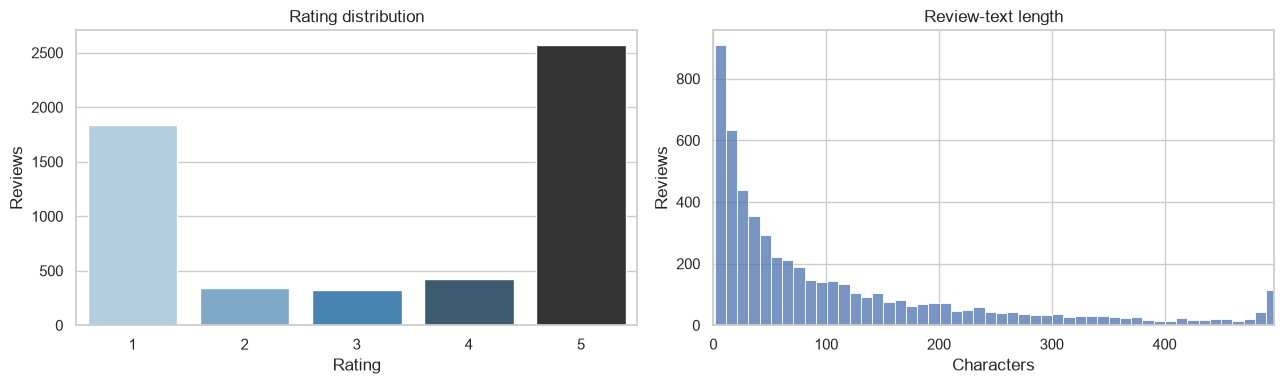

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=df, x='rating', hue='rating', legend=False, palette='Blues_d', ax=axes[0])
axes[0].set(title='Rating distribution', xlabel='Rating', ylabel='Reviews')
sns.histplot(data=df, x='review_text_length', bins=50, ax=axes[1], color='#4C72B0')
axes[1].set(title='Review-text length', xlabel='Characters', ylabel='Reviews', xlim=(0, df['review_text_length'].quantile(.99)))
fig.tight_layout()
fig.savefig(ARTIFACTS / 'review_characteristics.png', dpi=160, bbox_inches='tight')
pd.DataFrame({'rating_share': df['rating'].value_counts(normalize=True).sort_index(), 'rating_count': df['rating'].value_counts().sort_index()})

In [4]:
df[['rating', 'review_text_length', 'thumbs_up_count']].describe(percentiles=[.25, .5, .75, .9, .95])

,rating,review_text_length,thumbs_up_count
count,5500.000000,5500.000000,5500.000000
mean,3.283818,108.363273,1.399636
std,1.807722,126.199560,15.175362
min,1.000000,1.000000,0.000000
25%,1.000000,17.000000,0.000000
50%,4.000000,56.000000,0.000000
75%,5.000000,151.000000,1.000000
90%,5.000000,305.000000,1.000000
95%,5.000000,417.000000,3.000000
max,5.000000,500.000000,614.000000


## 2. Metadata coverage
Coverage refers to non-null values among retained clean records. A blank developer reply is expected for many reviews and is not necessarily a data defect.

,field,coverage_pct
0,rating,100.000000
1,review timestamp,100.000000
2,app version,85.563636
3,developer reply,13.272727
4,reply timestamp,13.272727


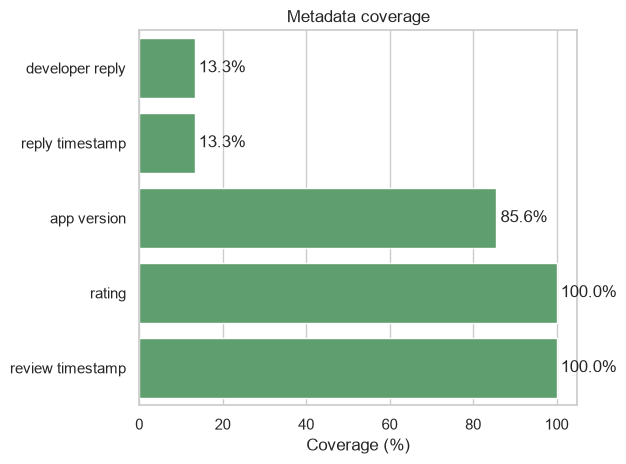

In [5]:
coverage_fields = {
    'rating': 'rating', 'review timestamp': 'review_created_at', 'app version': 'app_version',
    'developer reply': 'reply_text', 'reply timestamp': 'reply_created_at',
}
coverage = pd.DataFrame({
    'field': list(coverage_fields),
    'coverage_pct': [100 * df[column].notna().mean() for column in coverage_fields.values()],
}).sort_values('coverage_pct')
ax = sns.barplot(data=coverage, x='coverage_pct', y='field', color='#55A868')
ax.set(title='Metadata coverage', xlabel='Coverage (%)', ylabel='')
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
plt.xlim(0, 105)
plt.tight_layout()
plt.savefig(ARTIFACTS / 'metadata_coverage.png', dpi=160, bbox_inches='tight')
coverage.sort_values('coverage_pct', ascending=False)

## 3. Data quality
The cleaning report describes raw-to-clean attrition. Re-run the pipeline before comparing it to a new collection.

In [6]:
pd.Series(quality, name='value').to_frame()

,value
generated_at,2026-10-01T00:22:56.783588+00:00
rows_read,5500
rows_retained,5500
invalid_or_missing_source_review_id,0
blank_review_text,0
invalid_rating,0
duplicates_removed,0
missing_by_column,"{'source_review_id': 0, 'package_name': 0, 'ap..."
reviews_by_category,"{'Health & Fitness': 1000, 'Shopping': 1000, '..."
reviews_by_app,"{'Duolingo': 500, 'Netflix': 500, 'MyFitnessPa..."


In [7]:
quality_by_app = (df.groupby(['category', 'app_name'], as_index=False)
    .agg(reviews=('source_review_id', 'size'), average_rating=('rating', 'mean'),
         median_text_length=('review_text_length', 'median'), app_version_coverage=('app_version', lambda s: 100 * s.notna().mean()),
         reply_coverage=('reply_text', lambda s: 100 * s.notna().mean()))
    .sort_values(['category', 'reviews'], ascending=[True, False]))
quality_by_app.round(2)

,category,app_name,reviews,average_rating,median_text_length,app_version_coverage,reply_coverage
0,Education,Duolingo,500,4.44,29.5,91.2,0.0
1,Entertainment,Netflix,500,4.19,29.0,82.4,0.0
2,Health & Fitness,MyFitnessPal,500,2.59,112.5,88.2,96.0
3,Health & Fitness,Nike Training Club,500,2.82,106.5,84.8,0.0
4,Music & Audio,Spotify,500,2.79,74.0,85.0,10.8
5,Shopping,Amazon Shopping,500,2.17,111.5,89.0,0.0
6,Shopping,eBay,500,3.05,80.0,85.4,0.4
7,Social,Discord,500,2.89,58.5,80.0,38.4
8,Social,Reddit,500,3.43,41.5,84.0,0.0
9,Travel & Local,Airbnb,500,3.85,38.0,86.8,0.0


## 4. Differences across apps and categories
Compare only groups with sufficient, similarly timed samples. This descriptive chart does not imply a causal product-quality ranking.

,category,reviews,average_rating,median_text_length
4,Shopping,1000,2.61,98.5
2,Health & Fitness,1000,2.71,108.5
3,Music & Audio,500,2.79,74.0
5,Social,1000,3.16,49.0
6,Travel & Local,1000,3.87,27.0
1,Entertainment,500,4.19,29.0
0,Education,500,4.44,29.5


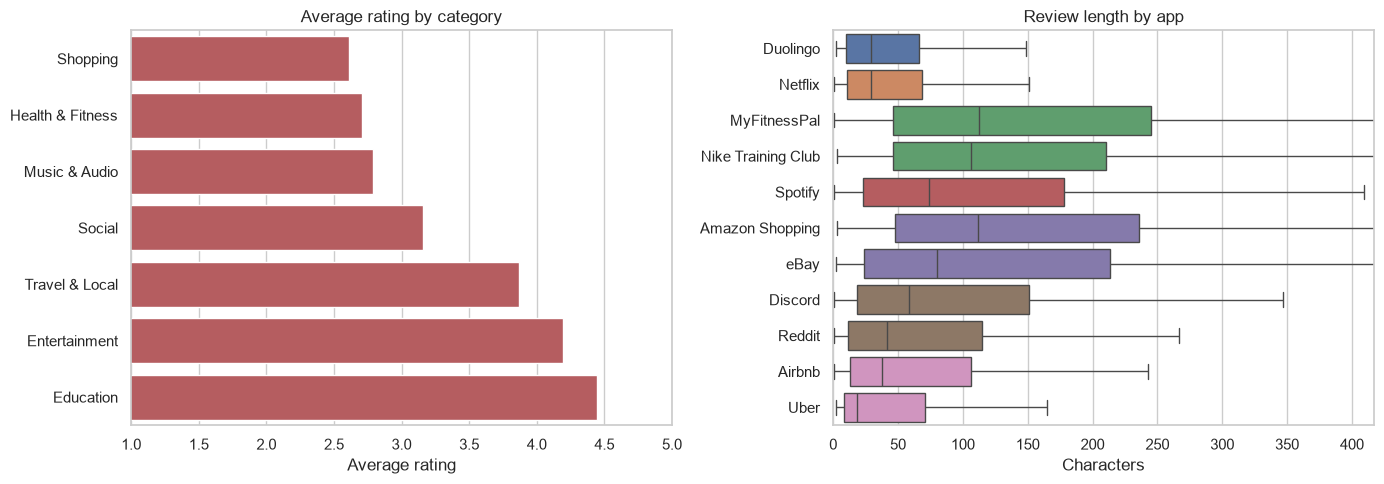

In [8]:
category_summary = (df.groupby('category', as_index=False)
    .agg(reviews=('rating', 'size'), average_rating=('rating', 'mean'), median_text_length=('review_text_length', 'median'))
    .sort_values('average_rating'))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=category_summary, y='category', x='average_rating', color='#C44E52', ax=axes[0])
axes[0].set(title='Average rating by category', xlim=(1, 5), xlabel='Average rating', ylabel='')
sns.boxplot(data=df, y='app_name', x='review_text_length', hue='category', legend=False, showfliers=False, ax=axes[1])
axes[1].set(title='Review length by app', xlim=(0, df['review_text_length'].quantile(.95)), xlabel='Characters', ylabel='')
fig.tight_layout()
fig.savefig(ARTIFACTS / 'app_category_differences.png', dpi=160, bbox_inches='tight')
category_summary.round(2)

## Reporting checklist

Copy actual metrics and carefully worded observations into `findings/EDA_FINDINGS_TEMPLATE.md`. Include the collection run/time, sample sizes, records removed, uneven samples, market/language configuration, and the unofficial-source limitation.